In [1]:
import pandas as pd
df = pd.read_csv('./data/marketing_AB.csv')
display(df.head())

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279668,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [3]:
df.groupby('test group').size()

test group
ad     564577
psa     23524
dtype: int64

In [2]:
map = {
    'Monday':0,
    'Tuesday':1,
    'Wednesday':2,
    'Thursday':3,
    'Friday':4,
    'Saturday':5,
    'Sunday':6
}
df['most_ads_day_num'] = df['most ads day'].map(map)

In [6]:
# check sample ratio mismatch (SRM)
from scipy.stats import chisquare
observed = df['test group'].value_counts().sort_index().values
expected = [len(df)/2, len(df)/2]
chi2, p_value = chisquare(observed, f_exp=expected)
print(p_value)

0.0


In [7]:
# conversion rate
df.groupby('test group')['converted'].mean()

test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

In [8]:
# randomization balance
num_cols = ['total ads', 'most_ads_day_num', 'most ads hour']
df.groupby('test group')[num_cols].mean()

,total ads,most_ads_day_num,most ads hour
test group,,,
ad,24.823365,3.028570,14.475900
psa,24.761138,2.952644,14.304923


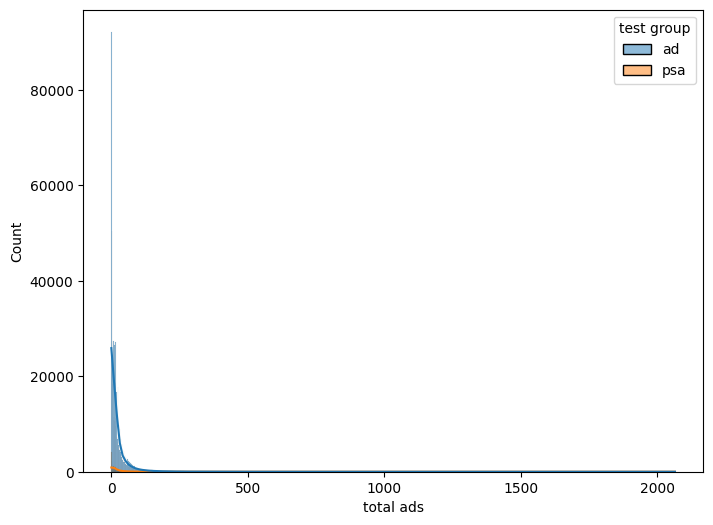

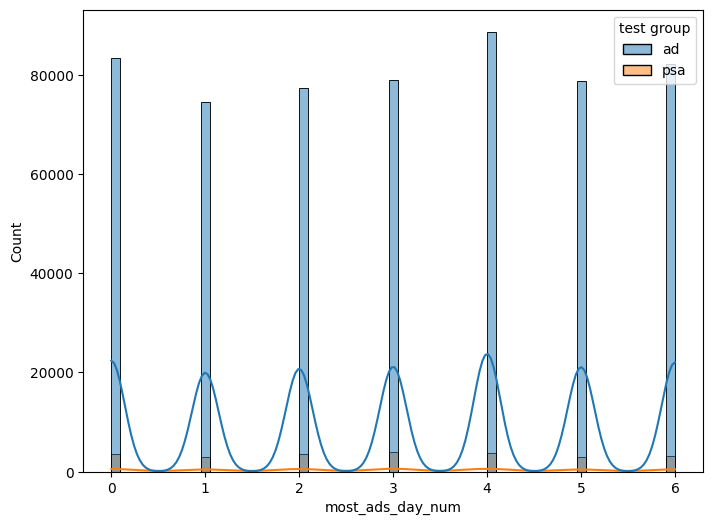

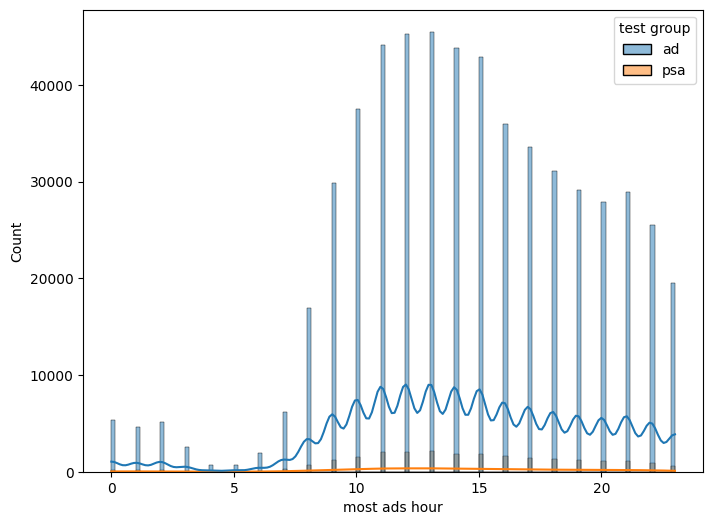

In [9]:
# distribution
import seaborn as sns
import matplotlib.pyplot as plt
for col in num_cols:
    plt.figure(figsize=(8,6))
    sns.histplot(data=df, x=col, hue='test group', kde=True)
    plt.show()

<Axes: xlabel='most_ads_day_num', ylabel='converted'>

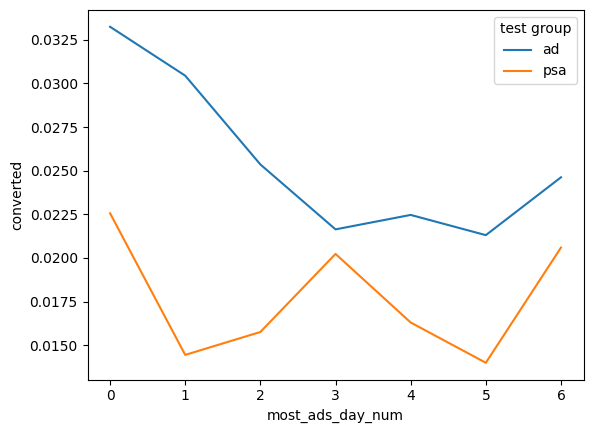

In [12]:
# check conversion by day
sns.lineplot(data=df.groupby(['test group', 'most_ads_day_num'])['converted'].mean().reset_index(),
             x='most_ads_day_num', y='converted', hue='test group')

In [3]:
# CLT assumption for z test
summary = df.groupby('test group')['converted'].agg(['sum','count'])
summary['failures'] = summary['count'] - summary['sum']
summary['p'] = summary['sum'] / summary['count']
summary['np'] = summary['count'] * summary['p']
print(summary)
# np>=5 and n(1-p)>=5, if assumption fails: fisher, bootstrap, and bayesian methods can be used

              sum   count  failures         p       np
test group                                            
ad          14423  564577    550154  0.025547  14423.0
psa           420   23524     23104  0.017854    420.0


In [8]:
# run z test
import numpy as np
def manual_cvr_ztest(df,group_col='test group'):
    summary = df.groupby(group_col)['converted'].agg(['count','mean']).reset_index()
    total = df['converted'].mean()
    p1 = summary.loc[summary[group_col] == 'ad', 'mean'].values[0]
    p2 = summary.loc[summary[group_col] == 'psa', 'mean'].values[0]
    n1 = summary.loc[summary[group_col] == 'ad', 'count'].values[0]
    n2 = summary.loc[summary[group_col] == 'psa', 'count'].values[0]
    p_pool = total
    se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z_stat = (p1 - p2) / se_pool
    from scipy.stats import norm
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))
    return z_stat, p_value

In [9]:
result = manual_cvr_ztest(df)
print(f"Z-statistic: {result[0]}, P-value: {result[1]}")

Z-statistic: 7.3700781265454145, P-value: 1.7053025658242404e-13
